In [25]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from pathlib import Path

legend_properties = {'weight': 'bold'}


In [26]:
# Define colors
# NUS two colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"

# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"

# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"

# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"


In [27]:
# Helper functions

def set_axis_style(ax):
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)


def final_value(matrix):
    """Return final-period value for each delegation level."""
    return np.array(matrix)[:, -1]


def load_delegation_data(base_folder, delegation_mode):
    """
    Load one delegation-mode result folder.

    Expected folder pattern:
    base_folder / f"Delegation_{delegation_mode}"

    Expected file prefix:
    f"{delegation_mode}_delegation"
    """
    data_folder = Path(base_folder) / f"Delegation_{delegation_mode}"
    output_prefix = delegation_mode + "_delegation"

    delegation_rate_list_file = data_folder / (output_prefix + "_rate_list")
    performance_file = data_folder / (output_prefix + "_performance")
    consensus_performance_file = data_folder / (output_prefix + "_consensus_performance")

    with open(delegation_rate_list_file, "rb") as infile:
        delegation_rate_list = pickle.load(infile)
    with open(performance_file, "rb") as infile:
        delegation_performance = pickle.load(infile)
    with open(consensus_performance_file, "rb") as infile:
        delegation_consensus_performance = pickle.load(infile)

    delegation_rate_array = np.array(delegation_rate_list)
    delegation_performance = np.array(delegation_performance)
    delegation_consensus_performance = np.array(delegation_consensus_performance)

    return {
        "mode": delegation_mode,
        "folder": data_folder,
        "delegation_rate_array": delegation_rate_array,
        "performance": delegation_performance,
        "consensus_performance": delegation_consensus_performance,
    }


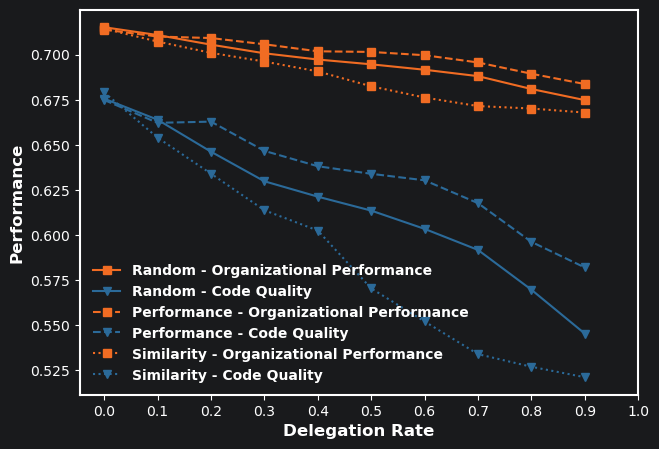

<Figure size 640x480 with 0 Axes>

In [28]:
# Integrated figure: final performance across all delegation modes

base_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4")
delegation_modes = ["random", "performance", "similarity"]

mode_styles = {
    "random": {"linestyle": "-",  "org_marker": "s", "code_marker": "v"},
    "performance": {"linestyle": "--", "org_marker": "s", "code_marker": "v"},
    "similarity": {"linestyle": ":",  "org_marker": "s", "code_marker": "v"},
}

fig, ax = plt.subplots(figsize=(7.2, 5.0))
set_axis_style(ax)

loaded_results = {}

for mode in delegation_modes:
    result = load_delegation_data(base_folder, mode)
    loaded_results[mode] = result

    delegation_rate_array = result["delegation_rate_array"]
    delegation_performance = result["performance"]
    delegation_consensus_performance = result["consensus_performance"]

    order = np.argsort(delegation_rate_array)

    x = delegation_rate_array[order]
    individual_final = np.array(final_value(delegation_performance))[order]
    consensus_final = np.array(final_value(delegation_consensus_performance))[order]

    style = mode_styles[mode]

    ax.plot(
        x, individual_final,
        linestyle=style["linestyle"],
        marker=style["org_marker"],
        color=nature_orange,
        label=f"{mode.capitalize()} - Organizational Performance"
    )
    ax.plot(
        x, consensus_final,
        linestyle=style["linestyle"],
        marker=style["code_marker"],
        color=nature_blue,
        label=f"{mode.capitalize()} - Code Quality"
    )

plt.xlabel(r"Delegation Rate", fontweight="bold", fontsize=12)
plt.ylabel("Performance", fontweight="bold", fontsize=12)
plt.xticks(np.arange(0, 1.01, 0.1))
ax.legend(frameon=False, ncol=1, fontsize=10, prop=legend_properties)

plt.show()
plt.clf()

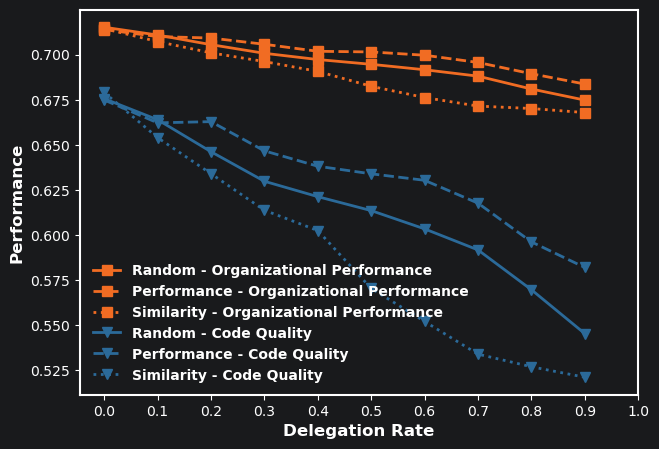

<Figure size 640x480 with 0 Axes>

In [29]:
# Integrated figure: final performance across all delegation modes

base_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4")
delegation_modes = ["random", "performance", "similarity"]

mode_styles = {
    "random": {"linestyle": "-",  "org_marker": "s", "code_marker": "v"},
    "performance": {"linestyle": "--", "org_marker": "s", "code_marker": "v"},
    "similarity": {"linestyle": ":",  "org_marker": "s", "code_marker": "v"},
}

fig, ax = plt.subplots(figsize=(7.2, 5.0))
set_axis_style(ax)

loaded_results = {}

for mode in delegation_modes:
    result = load_delegation_data(base_folder, mode)
    loaded_results[mode] = result

    delegation_rate_array = result["delegation_rate_array"]
    delegation_performance = result["performance"]
    delegation_consensus_performance = result["consensus_performance"]

    order = np.argsort(delegation_rate_array)

    x = delegation_rate_array[order]
    individual_final = np.array(final_value(delegation_performance))[order]
    consensus_final = np.array(final_value(delegation_consensus_performance))[order]

    style = mode_styles[mode]

    ax.plot(
        x,
        individual_final,
        linestyle=style["linestyle"],
        marker=style["org_marker"],
        color=nature_orange,
        linewidth=2,
        markersize=7,
        label=f"{mode.capitalize()} - Organizational Performance"
    )

    ax.plot(
        x,
        consensus_final,
        linestyle=style["linestyle"],
        marker=style["code_marker"],
        color=nature_blue,
        linewidth=2,
        markersize=7,
        label=f"{mode.capitalize()} - Code Quality"
    )

plt.xlabel(r"Delegation Rate", fontweight="bold", fontsize=12)
plt.ylabel("Performance", fontweight="bold", fontsize=12)
plt.xticks(np.arange(0, 1.01, 0.1))

# Reorder legend:
# Random Org, Performance Org, Similarity Org,
# Random Code, Performance Code, Similarity Code
handles, labels = ax.get_legend_handles_labels()
legend_order = [0, 2, 4, 1, 3, 5]

ax.legend(
    [handles[i] for i in legend_order],
    [labels[i] for i in legend_order],
    frameon=False,
    ncol=1,
    fontsize=10,
    prop=legend_properties,
)

plt.show()
plt.clf()

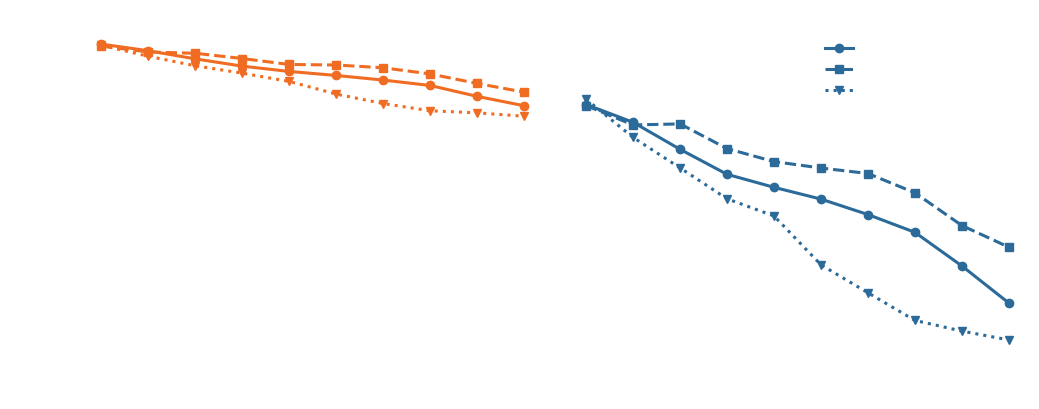

In [30]:
# Integrated figure: final performance across all delegation modes
# Cleaner two-panel version

base_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4")
delegation_modes = ["random", "performance", "similarity"]

mode_labels = {
    "random": "Random",
    "performance": "Performance-based",
    "similarity": "Similarity-based",
}

mode_styles = {
    "random": {"linestyle": "-",  "marker": "o"},
    "performance": {"linestyle": "--", "marker": "s"},
    "similarity": {"linestyle": ":",  "marker": "v"},
}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharex=True, sharey=True)

# Transparent figure background
fig.patch.set_alpha(0)

for ax in axes:
    set_axis_style(ax)
    ax.set_facecolor("none")   # transparent axes background
    ax.set_xticks(np.arange(0, 1.01, 0.1))
    ax.tick_params(axis="both", labelsize=10)
    # ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.25)

loaded_results = {}

for mode in delegation_modes:
    result = load_delegation_data(base_folder, mode)
    loaded_results[mode] = result

    delegation_rate_array = result["delegation_rate_array"]
    order = np.argsort(delegation_rate_array)
    x = delegation_rate_array[order]

    individual_final = np.array(final_value(result["performance"]))[order]
    consensus_final = np.array(final_value(result["consensus_performance"]))[order]

    style = mode_styles[mode]

    axes[0].plot(
        x,
        individual_final,
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.2,
        markersize=6,
        color=nature_orange,
        label=mode_labels[mode],
    )

    axes[1].plot(
        x,
        consensus_final,
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.2,
        markersize=6,
        color=nature_blue,
        label=mode_labels[mode],
    )

axes[0].set_title(
    "Organizational Performance",
    fontsize=12,
    fontweight="bold",
)

axes[1].set_title(
    "Code Quality",
    fontsize=12,
    fontweight="bold",
)

axes[0].set_xlabel(
    "Delegation Rate",
    fontsize=11,
    fontweight="bold",
)

axes[1].set_xlabel(
    "Delegation Rate",
    fontsize=11,
    fontweight="bold",
)

axes[0].set_ylabel(
    "Final Performance",
    fontsize=11,
    fontweight="bold",
)

axes[1].legend(
    frameon=False,
    fontsize=10,
    loc="best",
    prop=legend_properties,
)

plt.tight_layout()

plt.savefig(
    "/Volumes/T7/data/dao-0310-23/V4_4/Delegation_performance/Delegation_modes_comparison.png",
    transparent=True,
    bbox_inches="tight",
    dpi=300,
)

plt.show()